In [25]:
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score

# 1. Load the pristine, 1Hz downsampled task (~2.5 MB)
df = pd.read_parquet("CH4_C2H4_1Hz.parquet")

# 2. Add Temporal Context (Crucial for MOX Sensor Hysteresis)
sensor_cols =[c for c in df.columns if c.startswith("s") and "_" in c]

for col in sensor_cols:
    df[f"{col}_delta"] = df[col].diff()    # Derivative (Velocity of reaction)
    df[f"{col}_lag10"] = df[col].shift(10) # Short-term memory (10 seconds ago)

# Drop the first 10 rows created by the .shift() logic
df = df.dropna()

# 3. Define X (Features) and y (Targets)
# X includes 16 raw sensors + 16 deltas + 16 lags = 48 features
feature_cols =[c for c in df.columns if c.startswith("s") and "_" in c]
X = df[feature_cols]
y = df[["methane_ppm", "ethylene_ppm"]]

# 4. Strict Temporal Split (First 80% Train, Last 20% Test)
# Time-series rule: NEVER use shuffle=True in train_test_split!
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training on {len(X_train)} contiguous time-steps...")

# 5. Fit & Evaluate
model = ExtraTreesRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(f"R2 Score (Multi-Output): {r2_score(y_test, preds):.4f}")

Training on 33420 contiguous time-steps...
R2 Score (Multi-Output): 0.6168


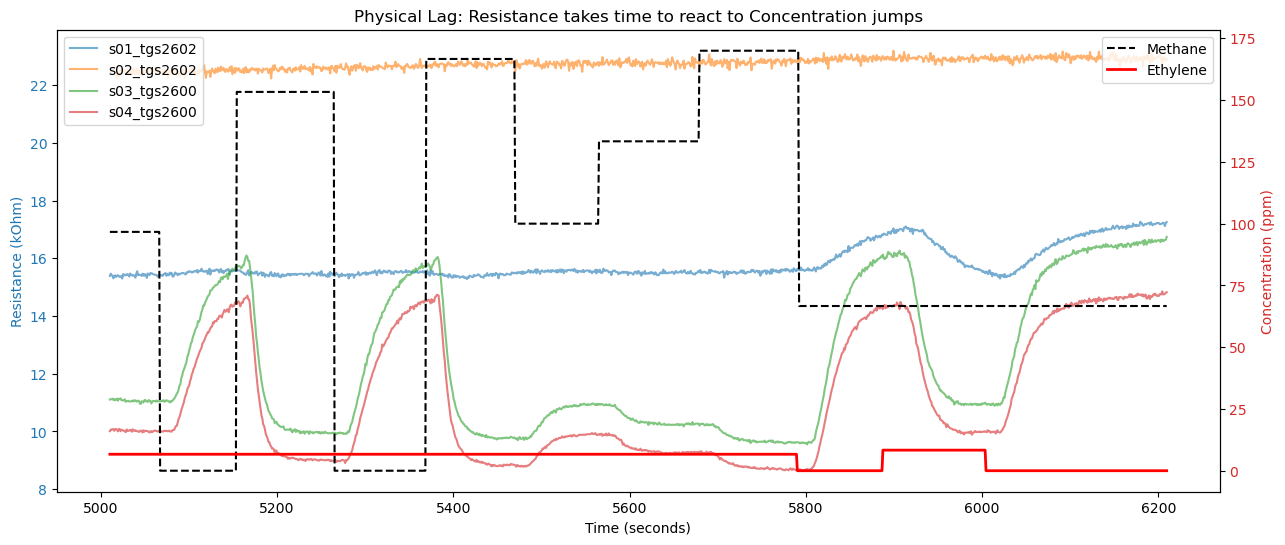

In [26]:
import matplotlib.pyplot as plt

# Get the first 4 sensor columns dynamically
sensors_to_plot = [c for c in subset.columns if c.startswith("s") and "_" in c][:4]

# Select a transition window
sample_range = subset.iloc[5000:6200] 

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Resistance (kOhm)', color='tab:blue')

# Plot the real sensor columns found in your dataframe
for col in sensors_to_plot:
    ax1.plot(sample_range['time_sec'], sample_range[col], alpha=0.6, label=col)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Plot Gas Concentration on right axis
ax2 = ax1.twinx()
ax2.set_ylabel('Concentration (ppm)', color='tab:red')
ax2.plot(sample_range['time_sec'], sample_range['methane_ppm'], 
         color='black', linestyle='--', label='Methane')
ax2.plot(sample_range['time_sec'], sample_range['ethylene_ppm'], 
         color='red', linewidth=2, label='Ethylene')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

plt.title("Physical Lag: Resistance takes time to react to Concentration jumps")
plt.show()

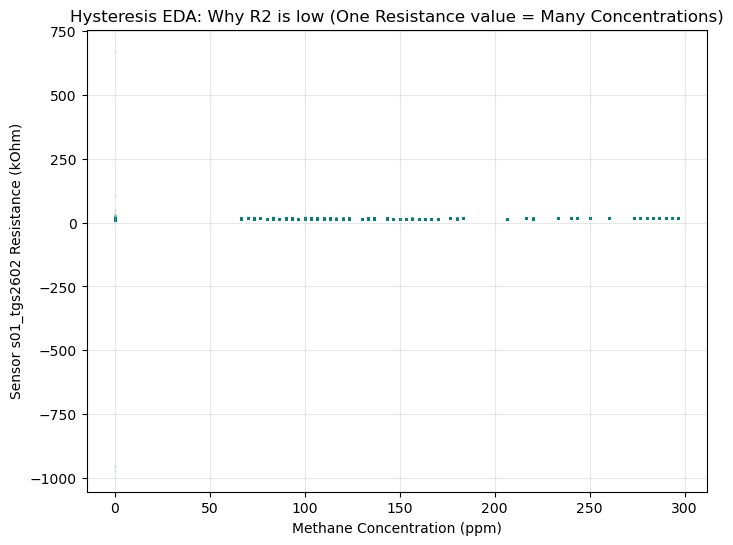

In [20]:
# Identify the first sensor column
first_sensor = [c for c in subset.columns if c.startswith("s")][0]

plt.figure(figsize=(8, 6))
plt.scatter(subset['methane_ppm'], subset[first_sensor], alpha=0.1, s=1, color='teal')
plt.xlabel('Methane Concentration (ppm)')
plt.ylabel(f'Sensor {first_sensor} Resistance (kOhm)')
plt.title("Hysteresis EDA: Why R2 is low (One Resistance value = Many Concentrations)")
plt.grid(True, alpha=0.3)
plt.show()

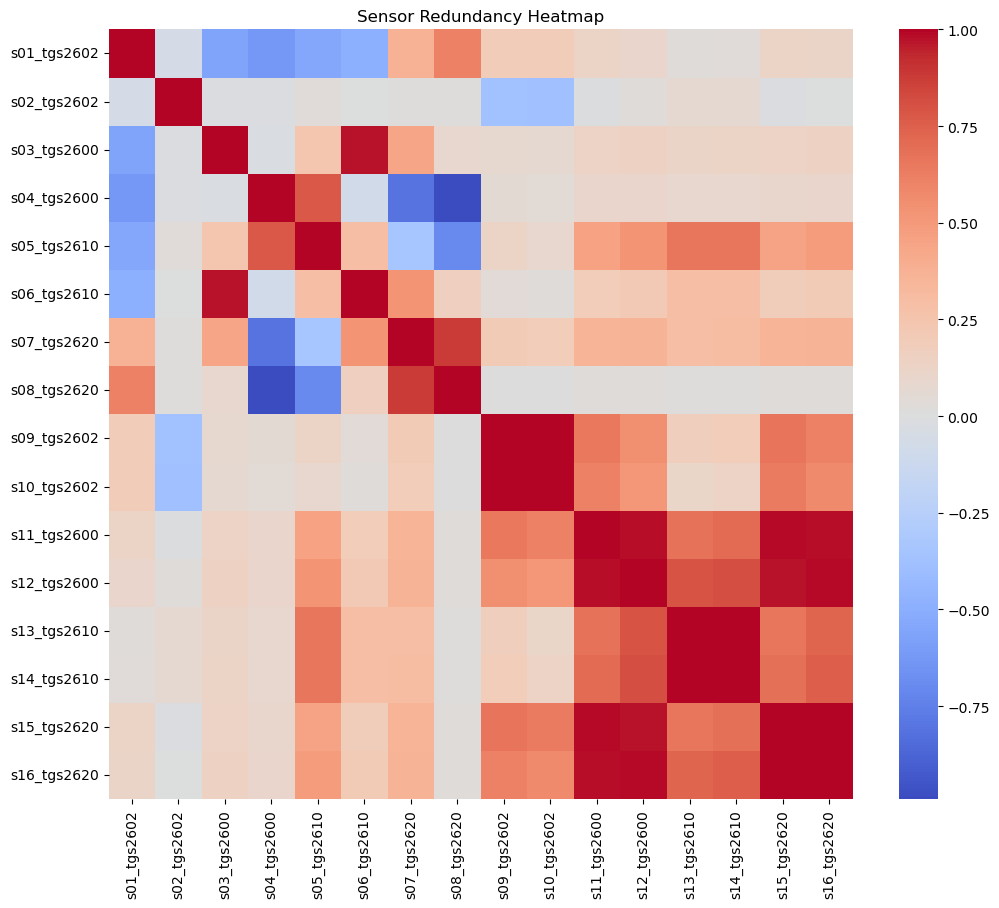

In [21]:
import seaborn as sns

plt.figure(figsize=(12, 10))
corr = subset[feature_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Sensor Redundancy Heatmap")
plt.show()